# Momentum Factor Research

This notebook walks through a **complete factor research workflow** using Factorium:

1. Load data from Binance
2. Explore the AggBar data structure
3. Build momentum factors (code-based & expression-based)
4. Visualize factor behavior
5. Run IC (Information Coefficient) analysis
6. Analyze quantile returns
7. Run a vectorized backtest
8. Generate a quick report

**Prerequisites**: `pip install factorium` (or `uv add factorium`)

## 1. Setup & Data Loading

We'll download 30 days of 1-minute futures data for 10 crypto symbols from Binance Vision.

In [1]:
from factorium import BinanceDataLoader, ResearchSession
from factorium.factors import FactorAnalyzer, CompositeFactor

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
SYMBOLS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "DOGEUSDT", "ADAUSDT", "AVAXUSDT", "DOTUSDT", "CAKEUSDT",
]

loader = BinanceDataLoader()

agg = loader.load_aggbar(
    symbols=SYMBOLS,
    data_type="aggTrades",
    market_type="futures",
    futures_type="um",
    days=30,
    bar_type="time",
    interval=60_000,       # 1-minute bars
)

print(f"Loaded {len(agg):,} bars")
print(f"Symbols: {agg.symbols}")
print(f"Columns: {agg.cols}")

2026-02-12 19:22:07,485 - INFO - Downloading 10 date ranges for 10 symbols...
2026-02-12 19:22:07,487 - ERROR - Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/novis/.local/share/uv/python/cpython-3.13.2-linux-x86_64-gnu/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x727d2837eac0> is already entered
2026-02-12 19:22:07,498 - ERROR - Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/novis/.local/share/uv/python/cpython-3.13.2-linux-x86_64-gnu/lib/python3.13/asyncio/events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x727d2837eac0> is al

Loaded 411,051 bars
Symbols: ['ADAUSDT', 'AVAXUSDT', 'BNBUSDT', 'BTCUSDT', 'CAKEUSDT', 'DOGEUSDT', 'DOTUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']
Columns: ['symbol', 'start_time', 'end_time', 'open', 'high', 'low', 'close', 'volume', 'vwap', 'num_buyer', 'num_seller', 'num_buyer_volume', 'num_seller_volume']


## 2. Exploring the AggBar

`AggBar` is a **multi-symbol OHLCV container** stored in long format. You can inspect it, convert to Polars/Pandas, and slice by time or symbols.

In [3]:
# Summary info per symbol
agg.info()

,num_kbar,start_time,end_time,num_nan
symbol,,,,
ADAUSDT,41106,2026-01-14 11:22:00,2026-02-12,0
AVAXUSDT,41106,2026-01-14 11:22:00,2026-02-12,0
BNBUSDT,41106,2026-01-14 11:22:00,2026-02-12,0
BTCUSDT,41106,2026-01-14 11:22:00,2026-02-12,0
CAKEUSDT,41097,2026-01-14 11:22:00,2026-02-12,0
DOGEUSDT,41106,2026-01-14 11:22:00,2026-02-12,0
DOTUSDT,41106,2026-01-14 11:22:00,2026-02-12,0
ETHUSDT,41106,2026-01-14 11:22:00,2026-02-12,0
SOLUSDT,41106,2026-01-14 11:22:00,2026-02-12,0


In [4]:
# View raw data as Polars DataFrame
agg.to_polars().head(10)

symbol,start_time,end_time,open,high,low,close,volume,vwap,num_buyer,num_seller,num_buyer_volume,num_seller_volume
str,i64,i64,f64,f64,f64,f64,f64,f64,"decimal[38,0]","decimal[38,0]",f64,f64
"""ADAUSDT""",1768389720000,1768389780000,0.4163,0.4163,0.416,0.4162,422468.0,0.416089,34,50,247651.0,174817.0
"""AVAXUSDT""",1768389720000,1768389780000,14.567,14.567,14.554,14.557,8092.0,14.557694,20,34,4859.0,3233.0
"""BNBUSDT""",1768389720000,1768389780000,931.8,931.8,931.28,931.56,231.68,931.516878,92,98,141.74,89.94
"""BTCUSDT""",1768389720000,1768389780000,94951.5,94951.6,94892.6,94910.0,53.578,94925.475406,305,563,25.438,28.14
"""CAKEUSDT""",1768389720000,1768389780000,2.0391,2.0391,2.0379,2.0381,4596.0,2.038591,30,28,3832.0,764.0
"""DOGEUSDT""",1768389720000,1768389780000,0.14685,0.14685,0.14673,0.14679,2.758362e6,0.146782,62,43,1.479317e6,1.279045e6
"""DOTUSDT""",1768389720000,1768389780000,2.257,2.257,2.252,2.255,61027.1,2.255454,26,21,20337.8,40689.3
"""ETHUSDT""",1768389720000,1768389780000,3295.7,3296.0,3294.42,3295.61,2396.264,3295.550097,528,547,1155.697,1240.567
"""SOLUSDT""",1768389720000,1768389780000,144.03,144.03,143.82,143.88,28761.51,143.913006,146,155,17777.74,10983.77


In [5]:
# Slice by symbols — creates a new AggBar
btc_eth = agg.slice(symbols=["BTCUSDT", "ETHUSDT"])
print(f"Sliced AggBar: {btc_eth.symbols}, {len(btc_eth):,} bars")

Sliced AggBar: ['BTCUSDT', 'ETHUSDT'], 82,212 bars


## 3. Building Momentum Factors

### 3.1 Code-Based Factor Construction

Extract a column from `AggBar` with `agg["close"]` to get a `Factor` object, then chain time-series and cross-sectional operators.

In [6]:
close = agg["close"]
volume = agg["volume"]

# Simple momentum: percentage change over 60 periods
momentum_60 = close.ts_delta(60) / close.ts_shift(60)
momentum_60.name = "momentum_60"

# Short-term momentum (20 periods)
momentum_20 = close.ts_delta(20) / close.ts_shift(20)
momentum_20.name = "momentum_20"

# Volatility-adjusted momentum
volatility = (close.ts_delta(1) / close.ts_shift(1)).ts_std(60)
vol_adj_momentum = momentum_60 / volatility
vol_adj_momentum.name = "vol_adj_momentum"

# Cross-sectional rank (normalized to [0, 1])
momentum_rank = momentum_60.cs_rank()
momentum_rank.name = "momentum_rank"

print("Factor shapes:")
print(f"  momentum_60:      {len(momentum_60):,} rows")
print(f"  vol_adj_momentum: {len(vol_adj_momentum):,} rows")
print(f"  momentum_rank:    {len(momentum_rank):,} rows")

Factor shapes:
  momentum_60:      411,607 rows
  vol_adj_momentum: 414,943 rows
  momentum_rank:    411,607 rows


### 3.2 Expression-Based Factor Construction

You can also define factors using string expressions via `ResearchSession.create_factor()`. This is useful for rapid experimentation.

In [7]:
session = ResearchSession(agg, default_frequency="1min")

# Same momentum factor, defined via expression
mom_expr = session.create_factor(
    "ts_delta(close, 60) / ts_shift(close, 60)",
    name="momentum_60_expr",
)

# A more complex expression: MA crossover signal
ma_cross = session.create_factor(
    "ts_mean(close, 10) - ts_mean(close, 30)",
    name="ma_crossover",
)

print(f"Expression-based momentum: {len(mom_expr):,} rows")
print(f"MA crossover signal:       {len(ma_cross):,} rows")

Expression-based momentum: 411,607 rows
MA crossover signal:       411,607 rows


## 4. Visualizing Factors

Use the `.plot` accessor on Factor objects to produce time series, heatmaps, and distributions.

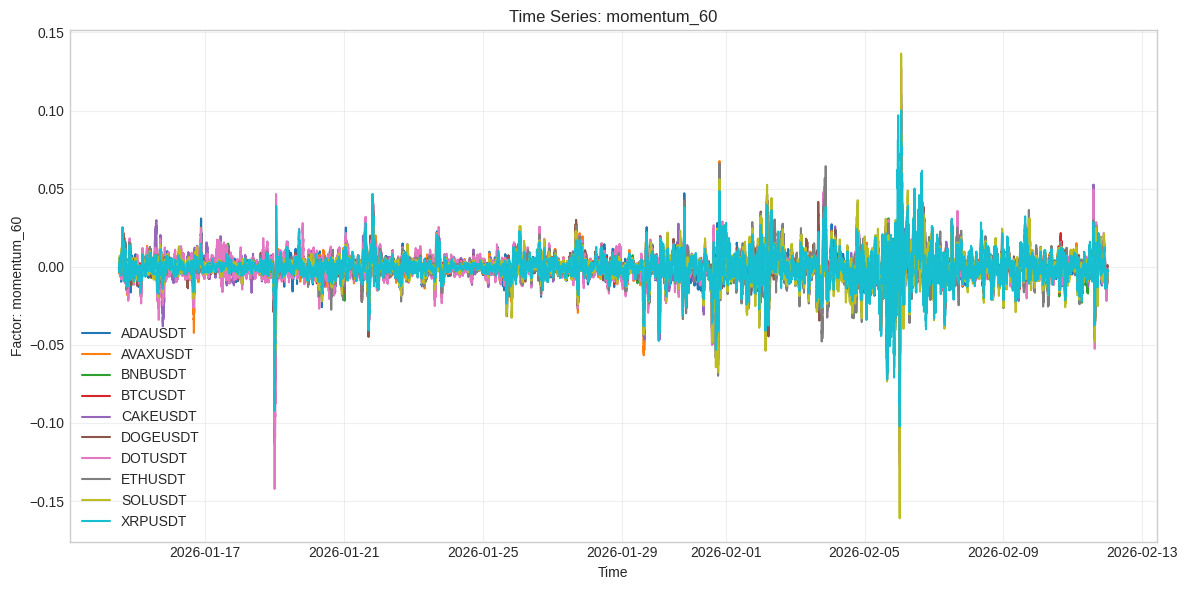

In [13]:
# Time series of momentum for a few symbols
momentum_60.plot()
plt.show()

## 5. IC (Information Coefficient) Analysis

The **IC** measures the rank correlation between factor values and subsequent returns. A consistently positive (or negative) IC indicates predictive power.

### 5.1 Single-Period IC

In [14]:
# Use ResearchSession for streamlined analysis
signal = momentum_rank  # Use ranked momentum as our signal

analysis = session.analyze(signal, periods=1)

print("IC Summary:")
print(analysis.ic_summary)
print()
print(f"IC Series shape: {analysis.ic_series.shape}")
print(analysis.ic_series.head())

2026-02-12 20:40:58,547 - INFO - prepare_data: 411607 rows -> 412109 rows (100.1% retained)


IC Summary:
{1: {'mean_ic': -0.026684615700049246, 'ic_std': 0.3761825466053544, 'ic_ir': -0.07093528378934481, 't-stat': -14.36627769408405}}

IC Series shape: (41017, 1)
               period_1
start_time             
1768393320000  0.369697
1768393380000  0.345455
1768393440000 -0.406061
1768393500000  0.260606
1768393560000  0.527273


### 5.2 Multi-Horizon IC Analysis

To understand how quickly a factor's signal decays, we compute IC across multiple forward horizons.

In [15]:
# Compute IC for multiple horizons
horizons = [1, 5, 10, 20, 60]
ic_results = {}

for h in horizons:
    result = session.analyze(signal, periods=h)
    ic_results[h] = result.ic_summary.get(h, {})

# Display IC decay table
ic_decay_df = pd.DataFrame(ic_results).T
ic_decay_df.index.name = "horizon"
print("IC Decay Analysis:")
ic_decay_df

2026-02-12 20:41:17,067 - INFO - prepare_data: 411607 rows -> 412109 rows (100.1% retained)
2026-02-12 20:41:18,547 - INFO - prepare_data: 411607 rows -> 412069 rows (100.1% retained)
2026-02-12 20:41:20,086 - INFO - prepare_data: 411607 rows -> 412019 rows (100.1% retained)
2026-02-12 20:41:21,566 - INFO - prepare_data: 411607 rows -> 411919 rows (100.1% retained)
2026-02-12 20:41:23,129 - INFO - prepare_data: 411607 rows -> 411519 rows (100.0% retained)


IC Decay Analysis:


,mean_ic,ic_std,ic_ir,t-stat
horizon,,,,
1,-0.026685,0.376183,-0.070935,-14.366278
5,-0.036314,0.383139,-0.094780,-19.194464
10,-0.040783,0.385369,-0.105829,-21.430799
20,-0.048677,0.386069,-0.126085,-25.529622
60,-0.041549,0.384516,-0.108055,-21.868208


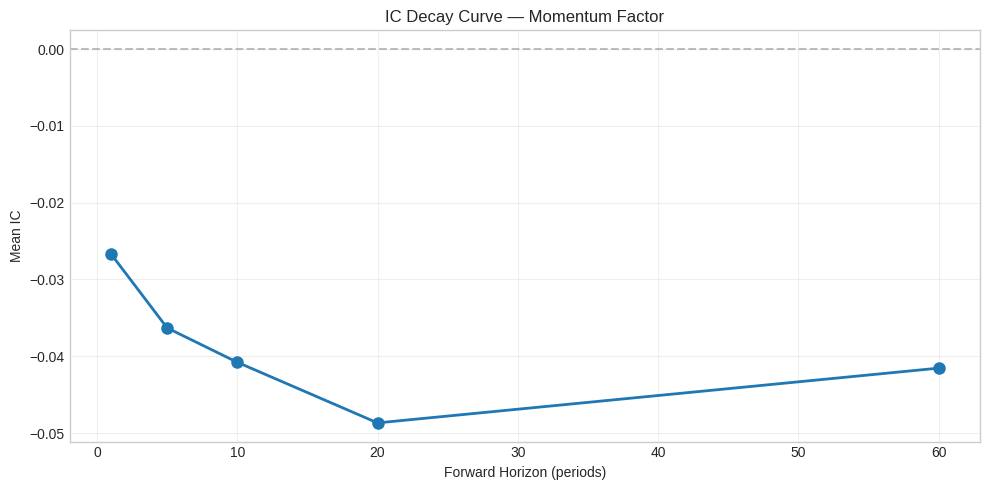

In [16]:
# Plot IC decay curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ic_decay_df.index, ic_decay_df["mean_ic"], "o-", linewidth=2, markersize=8)
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Forward Horizon (periods)")
ax.set_ylabel("Mean IC")
ax.set_title("IC Decay Curve — Momentum Factor")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Quantile Analysis

Split the cross-section into quantiles by factor value and examine the mean returns of each group. A monotonic pattern (Q1 < Q2 < ... < Q5) indicates strong linear predictive power.

In [ ]:
# Use FactorAnalyzer directly for more control
analyzer = FactorAnalyzer(signal, agg, quantiles=5)

# Prepare data: align factor values with forward returns
analyzer.prepare_data(price_col="close", periods=[1])

# Quantile returns
analyzer.plot_quantile_returns(quantiles=5, period=1)
plt.show()

In [ ]:
# Cumulative returns by quantile (includes Long-Short portfolio)
analyzer.plot_cumulative_returns(quantiles=5, period=1, long_short=True)
plt.show()

In [19]:
# IC time series plot
analyzer.plot_ic(period=1, method="rank", plot_type="ts")
plt.show()

ValueError: Data not prepared. Call prepare_data() first.

## 7. Backtesting

Run a **market-neutral vectorized backtest** using the momentum signal. The backtester:
- Converts signals to portfolio weights (cross-sectional normalization)
- Handles transaction costs
- Tracks equity, returns, and positions over time

In [ ]:
# Market-neutral backtest
result = session.backtest(
    signal,
    neutralization="market",
    transaction_cost=0.0003,
)

# Key performance metrics
print("Backtest Metrics:")
for key, val in result.metrics.items():
    if isinstance(val, float):
        print(f"  {key:25s}: {val:>10.4f}")
    else:
        print(f"  {key:25s}: {val}")

In [ ]:
# Plot equity curve
equity = result.equity_curve.to_pandas()
equity["timestamp"] = pd.to_datetime(equity["start_time"], unit="ms")

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(equity["timestamp"], equity["equity"], linewidth=1.5)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Equity")
ax.set_title("Momentum Factor — Equity Curve (Market Neutral)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Plot returns distribution
returns = result.returns.to_pandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns["portfolio_return"].dropna(), bins=100, alpha=0.75, edgecolor="black", linewidth=0.5)
ax.axvline(x=0, color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("Return")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Portfolio Returns")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Quick Report

`ResearchSession.quick_report()` combines IC analysis and backtesting into a single text summary — great for rapid iteration.

In [ ]:
report = session.quick_report(signal)
print(report)

## 9. Summary & Next Steps

In this notebook we:
- Loaded multi-symbol 1-minute data from Binance using `BinanceDataLoader`
- Built momentum factors via both **code-based** and **expression-based** methods
- Visualized factor behavior with time series, distributions, and heatmaps
- Computed IC and analyzed its decay across multiple horizons
- Ran a market-neutral backtest and examined performance metrics

**Next notebooks to explore:**
- `02_mean_reversion_factor.ipynb` — Mean reversion with volatility normalization
- `03_data_loading_and_exploration.ipynb` — Deep dive into AggBar and data loading
- `04_multi_factor_combination.ipynb` — Combine multiple factors and compare performance